# **Calculative Foundation Project**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, inv, det, eig
from scipy.linalg import lu, svd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# **Create Dataset (Students × Subjects)**

In [2]:
data = {
    "Math": [78, 85, 90, 66, 72],
    "Physics": [82, 88, 94, 70, 75],
    "Chemistry": [80, 86, 91, 65, 74],
    "English": [75, 79, 84, 68, 73]
}

df = pd.DataFrame(data)
df

,Math,Physics,Chemistry,English
0,78,82,80,75
1,85,88,86,79
2,90,94,91,84
3,66,70,65,68
4,72,75,74,73


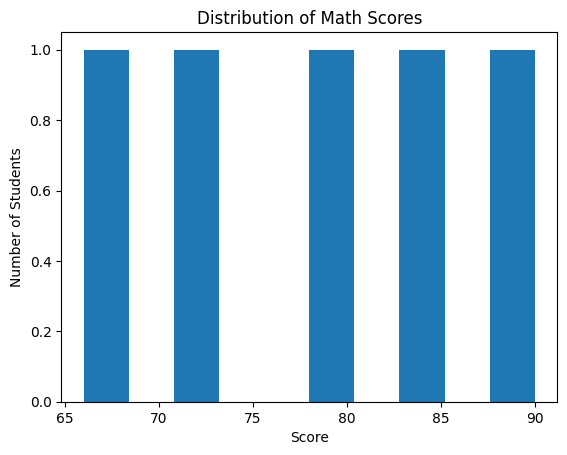

In [30]:
plt.hist(df['Math'], bins=10)
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()

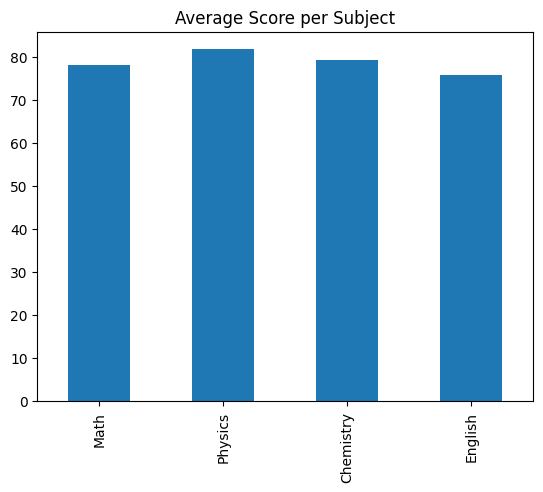

In [31]:
df.mean().plot(kind='bar')
plt.title("Average Score per Subject")
plt.show()

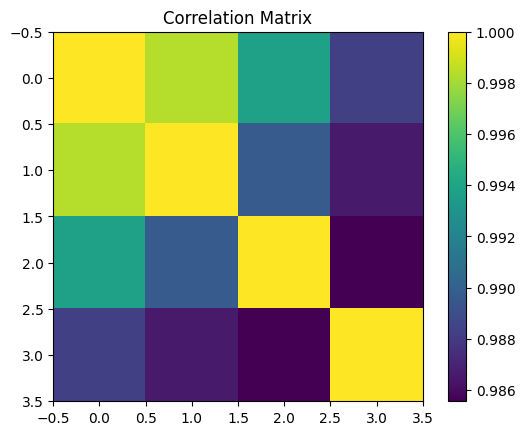

In [33]:
plt.imshow(df.corr())
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

**Matrix form:**

In [3]:
A = df.values
A

array([[78, 82, 80, 75],
       [85, 88, 86, 79],
       [90, 94, 91, 84],
       [66, 70, 65, 68],
       [72, 75, 74, 73]])

# **VECTOR & MATRIX FUNDAMENTALS**

**Represent each student as a vector**

In [4]:
v1 = df.iloc[0].values
v2 = df.iloc[1].values

print("Student 1 Vector:", v1)
print("Student 2 Vector:", v2)

Student 1 Vector: [78 82 80 75]
Student 2 Vector: [85 88 86 79]


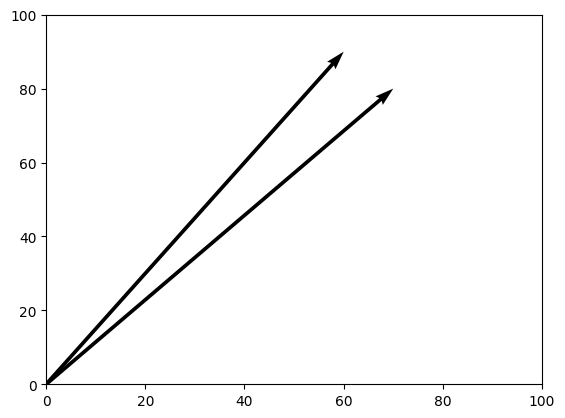

In [35]:
v1 = np.array([70,80])
v2 = np.array([60,90])

plt.quiver(0,0,v1[0],v1[1],angles='xy',scale_units='xy',scale=1)
plt.quiver(0,0,v2[0],v2[1],angles='xy',scale_units='xy',scale=1)
plt.xlim(0,100)
plt.ylim(0,100)
plt.show()

**Compute Norm-1 and Norm-2**

In [5]:
norm1 = norm(v1, 1)
norm2 = norm(v1)

print("L1 Norm:", norm1)
print("L2 Norm:", norm2)

L1 Norm: 315.0
L2 Norm: 157.58489775356014


**Dot Product & Angle Between Vectors**

In [6]:
dot_product = np.dot(v1, v2)

angle = np.arccos(dot_product / (norm(v1)*norm(v2)))
angle_deg = np.degrees(angle)

print("Dot Product:", dot_product)
print("Angle (degrees):", angle_deg)

Dot Product: 26651
Angle (degrees): 0.6695276328537625


**Cross Product**

In [7]:
cross_product = np.cross(v1[:3], v2[:3])
print("Cross Product:", cross_product)

Cross Product: [  12   92 -106]


**Projection of One Vector onto Another**

In [8]:
projection = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
print("Projection of v1 onto v2:", projection)

Projection of v1 onto v2: [79.19090401 81.98587709 80.1225617  73.60095784]


# **MATRIX OPERATIONS**

**Matrix Addition**

In [11]:
B = A + A

print("Addition:\n", B)

Addition:
 [[156 164 160 150]
 [170 176 172 158]
 [180 188 182 168]
 [132 140 130 136]
 [144 150 148 146]]


**Matrix Multiplication**

In [13]:
C = np.dot(A.T, A)

print("Multiplication:\n", C)

Multiplication:
 [[30949 32356 31358 29869]
 [32356 33829 32782 31233]
 [31358 32782 31778 30260]
 [29869 31233 30260 28875]]


**Transpose**

In [15]:
A_transpose
print("Transpose:\n", A)

Transpose:
 [[78 82 80 75]
 [85 88 86 79]
 [90 94 91 84]
 [66 70 65 68]
 [72 75 74 73]]


**Determinant**

In [17]:
square_matrix = A[:4,:4]

print("Determinant:", det(square_matrix))

Determinant: 716.0000000000065


**Inverse**

In [18]:
print("Inverse:\n", inv(square_matrix))

Inverse:
 [[-0.70949721  1.06703911 -0.49441341  0.15363128]
 [-0.02793296 -1.39106145  1.38407821 -0.06284916]
 [ 0.58100559  0.13407821 -0.48882682 -0.19273743]
 [ 0.16201117  0.26815642 -0.47765363  0.11452514]]


# **EIGENVALUES & DECOMPOSITION**

**Covariance Matrix**

In [20]:
cov_matrix = np.cov(A.T)
cov_matrix

array([[ 93.2 ,  93.05,  97.7 ,  57.8 ],
       [ 93.05,  93.2 ,  97.3 ,  57.7 ],
       [ 97.7 ,  97.3 , 103.7 ,  60.8 ],
       [ 57.8 ,  57.7 ,  60.8 ,  36.7 ]])

**Eigenvalues & Eigenvectors**

In [21]:
eigenvalues, eigenvectors = eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [3.24879395e+02 9.54405217e-02 1.09829685e+00 7.26867623e-01]
Eigenvectors:
 [[-0.53518145  0.78877294  0.2460104  -0.17577527]
 [-0.53438529 -0.58643027  0.57501104 -0.19973533]
 [-0.56306013 -0.18349463 -0.7802818  -0.20113012]
 [-0.3331313  -0.01632517  0.00122452  0.94273831]]


**LU Decomposition**

In [22]:
P, L, U = lu(square_matrix)

print("L Matrix:\n", L)
print("U Matrix:\n", U)

L Matrix:
 [[ 1.          0.          0.          0.        ]
 [ 0.73333333  1.          0.          0.        ]
 [ 0.86666667  0.5         1.          0.        ]
 [ 0.94444444 -0.72916667 -0.60416667  1.        ]]
U Matrix:
 [[90.         94.         91.         84.        ]
 [ 0.          1.06666667 -1.73333333  6.4       ]
 [ 0.          0.          2.         -1.        ]
 [ 0.          0.          0.          3.72916667]]


**Singular Value Decomposition (SVD)**

In [23]:
U, S, VT = svd(A)

print("Singular Values:", S)

Singular Values: [354.10244446   6.141424     2.08445446   0.62991135]


# **DIMENSIONALITY REDUCTION**

**PCA (Reduce to 2D)**

In [24]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(A)

print(pca_result)

[[  0.18378384   0.55940492]
 [ 11.84725173   0.06405857]
 [ 22.21042789  -0.72077329]
 [-23.42883815  -1.28399308]
 [-10.8126253    1.38130288]]


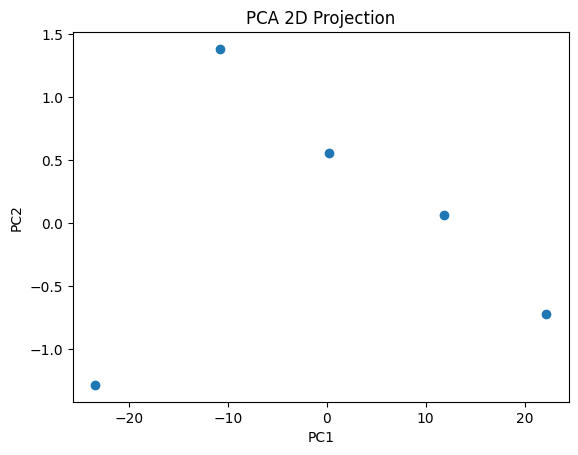

In [32]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(df)

plt.scatter(reduced[:,0], reduced[:,1])
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**LDA Classification**

In [26]:
labels = ["Above","Above","Above","Below","Below"]

lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(A, labels)

print(lda_result)

[[-0.96845753]
 [-3.38693255]
 [-2.10411157]
 [ 3.41932879]
 [ 3.04017286]]
